### The geometric object

Fix an observed document/input \(X\) (here: the OBBA supplemental text we parsed into headline numbers).

Let the **parameter space** be the two continuous coordinates \((\Delta,\beta)\in\mathbb R^2\), where:

- \(\Delta\) is the Medicaid alternative-specific-constant (ASC) shift (procedural burden / verification friction),
- \(\beta\) is the responsiveness scaling parameter in the discrete choice model,

and let the **choice-set assumption** be a discrete coordinate

$$
\text{cs}\in\{\text{full},\text{restricted}\}.
$$

Each value of `cs` defines a different “sheet” of the model.

Define the toy model map

$$
\Phi_{\text{cs}}:\underbrace{\mathbb R^2}_{(\Delta,\beta)} \to \underbrace{\mathbb R^2}_{(\text{Def},\,U)},
\qquad
(\Delta,\beta)\mapsto \big(\text{Def}(\Delta,\beta;\text{cs}),\ U(\Delta,\beta;\text{cs})\big),
$$

where:
- \(\text{Def}\) is the deficit reduction over 2025–2034 (in \$ billions),
- \(U\) is the increase in uninsured in 2034 (in millions).

**Assumptions as subsets.**  
In parameter space, restrictions like \(\beta\in[\underline\beta,\overline\beta]\) or “choice set restricted” correspond to restricting attention to a subset

$$
S \subset \mathbb R^2 \times \{\text{full},\text{restricted}\}.
$$

**Attainable region.**  
In outcome space, the set of implied budget outcomes is the image

$$
\Phi(S) \subset \mathbb R^2,
$$

which we visualize as an attainable region in \((\text{Def},U)\)-space.

**Fibers / level sets.**  
A “fiber” in this geometry is a level set of the map. For example,

$$
\{(\Delta,\beta):\text{Def}(\Delta,\beta)=317\}
$$

is a curve (a contour) in \((\Delta,\beta)\)-space.

---

### Minimal formulas (what the code computes)

**Toy logit choice probabilities.**  
For alternatives \(h\) in the choice set implied by \(\text{cs}\),

$$
P_{\Delta,\beta,\text{cs}}(h) \propto \exp\big(\beta V(h) + \delta(h)\big),
\quad \text{with} \quad \delta(\text{Medicaid})\leftarrow \delta(\text{Medicaid})+\Delta.
$$

**Level of Medicaid losses (needs a denominator).**  
Given a denominator \(N_{\text{subj},2034}\) (affected population in 2034 absent policy),

$$
N_{\text{loss},2034}(\Delta,\beta)=\big(1-P(\text{Medicaid})\big)\,N_{\text{subj},2034}.
$$

**Toy calibrated budget identity.**  
Let \(s_{\text{ppy}}\) denote a calibrated savings-per-person-year parameter, and let “ramp years” be the policy-window multiplier. Then

$$
\text{Def}(\Delta,\beta)=s_{\text{ppy}}\cdot N_{\text{loss},2034}(\Delta,\beta)\cdot (\text{ramp years}).
$$

**Uninsured in 2034.**  
Let \(\Pr(\text{Uninsured}\mid \text{Leave Medicaid})\) be implied by the choice probabilities. Then

$$
U(\Delta,\beta)=\Pr(\text{Uninsured}\mid \text{Leave Medicaid})\cdot N_{\text{loss},2034}(\Delta,\beta).
$$


Extracted OBBA 71119 (from PDF text):
  total lose Medicaid 2034 (m): 5.555
  uninsured increase 2034 (m): 5.300
  uninsured share among losers: 0.954095
  deficit reduction 2025–2034 ($B): 317.0

Toy accounting calibration:
  s_ppy = deficit / (N_loss_2034 * ramp_years) = 8,152 $ per person-year losing Medicaid

Formulas used in the demo:
  N_loss_2034(m) = (1 - P_post(Medicaid)) * N_subject_2034(m)
  Deficit($B) = [s_ppy * (N_loss_2034*1e6) * 7.0] / 1e9
  Uninsured_2034(m) = Pr(Uninsured | Leave Medicaid) * N_loss_2034(m)

Using N_subject_2034_m=15.0, target P_post(Medicaid) = 0.629667

Calibrated substitute accessibility shift (applied to ESI & Nongroup ASCs) so reference matches OBBA uninsured share:
  sub_shift = -4.040705
  DELTAS_CAL = {'Medicaid': 2.0, 'Uninsured': 0.0, 'ESI': -3.540704518556595, 'Nongroup': -3.8407045185565947}

Saved plots:
  geometry_parameter_space_contours_full.png
  geometry_parameter_space_contours_restricted.png
  geometry_outcome_space_attainable_regi

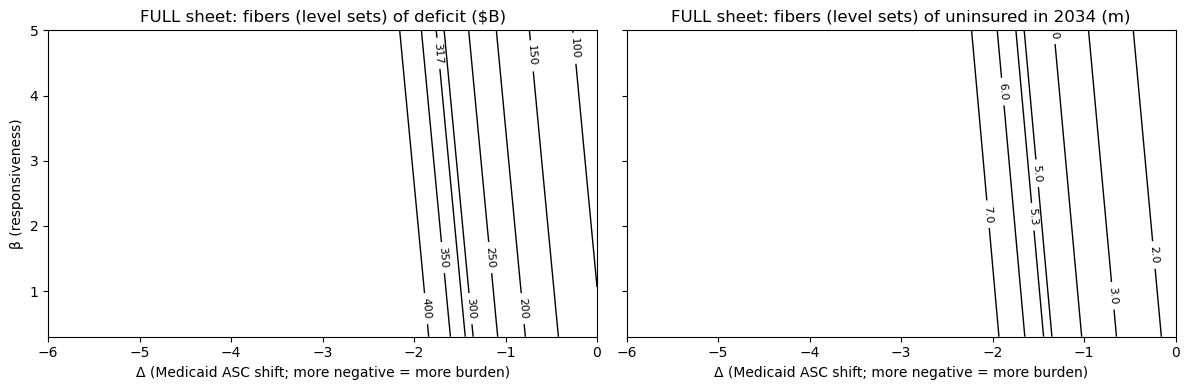

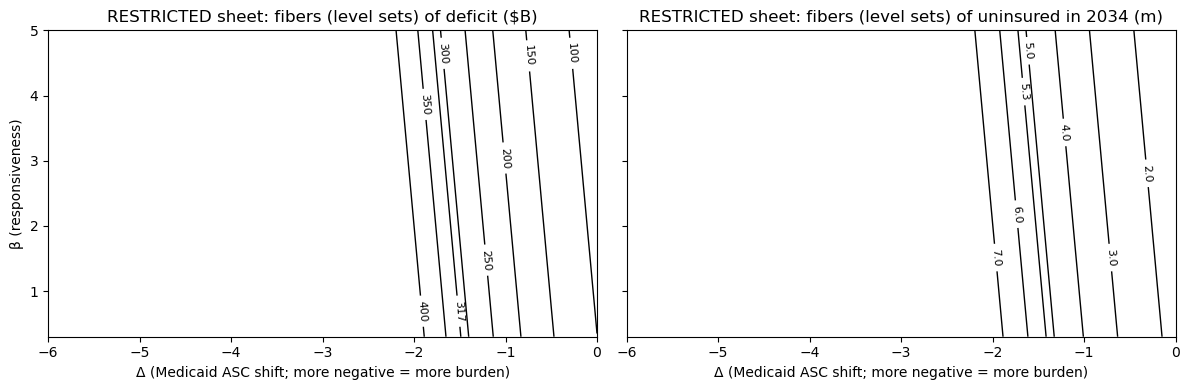

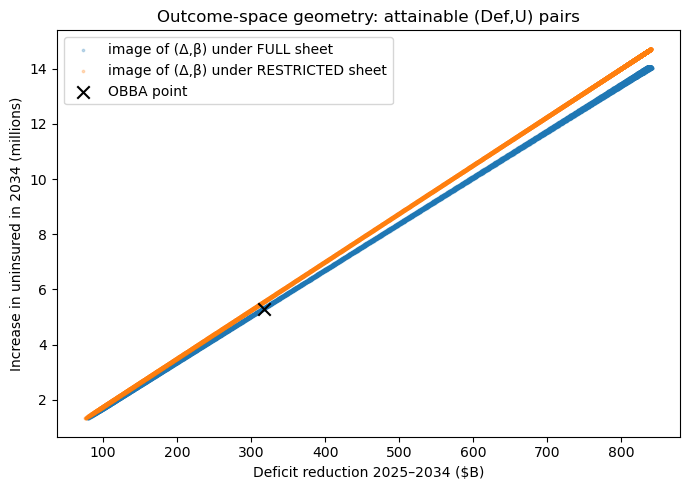

In [1]:
"""
Geometry demo (toy, OBBA 71119):

Goal:
- Treat (Δ, β, cs) as a *parameter space* (Δ = Medicaid ASC shift; β = responsiveness scaling; cs = choice-set regime).
- Define a model map Φ_cs : (Δ, β) -> (Def, U) where:
    Def = deficit reduction over 2025–2034 ($B)
    U   = increase in uninsured in 2034 (millions)
- Visualize:
    (i) fibers / level sets in parameter space (contours of Def and U in the (Δ,β) plane)
    (ii) attainable regions in outcome space (images of the grid under Φ_cs)

This is NOT HISIM2 and does NOT reproduce CBO scoring.
It is an auditable illustration of: assumptions-as-coordinates -> model map -> geometry of outcomes.

Inputs:
- Local OBBA supplemental PDF: "PL-119-21-Medicaid _0.pdf"
Outputs (PNG):
- geometry_parameter_space_contours_full.png
- geometry_parameter_space_contours_restricted.png
- geometry_outcome_space_attainable_regions.png
"""

import re
from pathlib import Path

import numpy as np
import pandas as pd
import pdfplumber
import matplotlib.pyplot as plt

# ============================================================
# 0) CONFIG
# ============================================================

OBBA_PDF = Path("PL-119-21-Medicaid _0.pdf")  # local file; no downloading

# Budget-window ramp approximation: 2027:1/3, 2028:2/3, 2029–2034:1 => 7 full-effect years
RAMP_EQUIV_YEARS = 7.0

# Denominator mapping level->share:
#   N_loss_2034(m) = (1 - P_post(Medicaid)) * N_subject_2034(m)
N_subject_2034_m = 15.0  # choose and document meaning (subject/enrolled/eligible absent policy)

# Discrete choice "coordinate system" knobs
CONSUMPTION_Y = 35000.0
DELTAS_BASE = {"Medicaid": 2.0, "Uninsured": 0.0, "ESI": 0.5, "Nongroup": 0.2}
CHOICE_SET_FULL = ("Medicaid", "Uninsured", "ESI", "Nongroup")
CHOICE_SET_RESTRICTED = ("Medicaid", "Uninsured")  # toy "choice-set restriction" sheet

# Parameter grid for geometry
DELTA_GRID = np.linspace(0.0, -6.0, 121)   # Δ: Medicaid ASC shift (more negative = more burden)
BETA_GRID  = np.linspace(0.3, 5.0, 121)    # β: responsiveness scaling

# Toy health spending states (only affects the relative attractiveness of alternatives)
RNG_SEED = 0
S = 14
UNINS_CAP = 2000.0
UNINS_COLLECTION_RATE = 0.2
MEDICAID_OOP_RATE = 0.05
ALPHA_BAD_DEBT = 0.25

# ============================================================
# 1) PDF utilities + OBBA extraction
# ============================================================

def pdf_to_text(pdf_path, max_pages=None):
    parts = []
    with pdfplumber.open(pdf_path) as pdf:
        pages = pdf.pages[:max_pages] if max_pages else pdf.pages
        for p in pages:
            parts.append(p.extract_text() or "")
    return "\n".join(parts)

def find_block(text, start_pat, end_pat=None, max_len=25000):
    m = re.search(start_pat, text, flags=re.IGNORECASE)
    if not m:
        return None
    start = m.start()
    if end_pat:
        n = re.search(end_pat, text[start:], flags=re.IGNORECASE)
        end = start + n.start() if n else min(len(text), start + max_len)
    else:
        end = min(len(text), start + max_len)
    return text[start:end]

def extract_float(pattern, s):
    m = re.search(pattern, s, flags=re.IGNORECASE | re.DOTALL)
    return float(m.group(1)) if m else None

assert OBBA_PDF.exists(), f"Missing OBBA PDF: {OBBA_PDF.resolve()}"
obba_text = pdf_to_text(OBBA_PDF)

block_71119 = find_block(
    obba_text,
    start_pat=r"Community Engagement Requirements\.\s*Section\s*71119",
    end_pat=r"Other Medicaid-Related Effects|Uncertainty"
)
if block_71119 is None:
    raise ValueError("Could not locate 71119 block. Adjust start/end regex.")

# Parse headline numbers used in the demo
N_fail_2034 = extract_float(r"about\s+(\d+(\.\d+)?)\s+million\s+in\s+2034.*?will lose\s+coverage", block_71119)
N_admin_2034 = extract_float(r"about\s+(\d+(\.\d+)?)\s+million\s+additional.*?lose Medicaid coverage in\s+2034", block_71119)
p_keep_pct = extract_float(r"about\s+(\d+(\.\d+)?)\s+percent.*?will keep their Medicaid\s+coverage", block_71119)
uninsured_2034 = extract_float(r"increase by\s+(\d+(\.\d+)?)\s+million\s+in\s+2034", block_71119)
deficit_red_B = extract_float(r"decrease deficits by\s+\$?(\d+(\.\d+)?)\s+billion", block_71119)

# Derived objects
p_keep = p_keep_pct / 100.0
N_loss_total_2034 = (1 - p_keep) * N_fail_2034 + N_admin_2034
uninsured_share_among_losers_obba = uninsured_2034 / N_loss_total_2034

print("\nExtracted OBBA 71119 (from PDF text):")
print(f"  total lose Medicaid 2034 (m): {N_loss_total_2034:.3f}")
print(f"  uninsured increase 2034 (m): {uninsured_2034:.3f}")
print(f"  uninsured share among losers: {uninsured_share_among_losers_obba:.6f}")
print(f"  deficit reduction 2025–2034 ($B): {deficit_red_B:.1f}")

# Calibrate a toy "federal savings per person-year losing Medicaid" so baseline matches OBBA
s_ppy = (deficit_red_B * 1e9) / (N_loss_total_2034 * 1e6 * RAMP_EQUIV_YEARS)

print("\nToy accounting calibration:")
print(f"  s_ppy = deficit / (N_loss_2034 * ramp_years) = {s_ppy:,.0f} $ per person-year losing Medicaid")

print("\nFormulas used in the demo:")
print("  N_loss_2034(m) = (1 - P_post(Medicaid)) * N_subject_2034(m)")
print(f"  Deficit($B) = [s_ppy * (N_loss_2034*1e6) * {RAMP_EQUIV_YEARS}] / 1e9")
print("  Uninsured_2034(m) = Pr(Uninsured | Leave Medicaid) * N_loss_2034(m)")

# Target post-policy Medicaid share implied by OBBA Medicaid losses + your chosen denominator
target_P_medicaid_post = 1.0 - (N_loss_total_2034 / N_subject_2034_m)
print(f"\nUsing N_subject_2034_m={N_subject_2034_m:.1f}, target P_post(Medicaid) = {target_P_medicaid_post:.6f}")

# ============================================================
# 2) Toy discrete choice model
# ============================================================

rng = np.random.default_rng(RNG_SEED)
p_state = np.ones(S) / S
H = np.sort(rng.lognormal(mean=8.0, sigma=0.7, size=S))  # synthetic annual spending states

def build_costs(H, medicaid_oop_rate=0.05, unins_cap=2000.0, unins_collection_rate=0.2):
    oop_med = medicaid_oop_rate * H
    oop_unins = np.minimum(H, unins_cap) + unins_collection_rate * np.maximum(0, H - unins_cap)
    baddebt = (1 - unins_collection_rate) * np.maximum(0, H - unins_cap)
    return oop_med, oop_unins, baddebt

def softmax(u):
    u = np.array(u, dtype=float)
    u = u - u.max()
    e = np.exp(u)
    return e / e.sum()

def V_alt(consumption, alt):
    """
    Deterministic index V(h). This is just a toy stand-in for the HISIM2-style expected-log structure.
    """
    oop_med, oop_unins, baddebt = build_costs(H, MEDICAID_OOP_RATE, UNINS_CAP, UNINS_COLLECTION_RATE)

    if alt == "Medicaid":
        net = consumption - oop_med
        return float(np.sum(p_state * np.log(np.maximum(net, 1.0))))
    if alt == "Uninsured":
        net = consumption - oop_unins - ALPHA_BAD_DEBT * baddebt
        return float(np.sum(p_state * np.log(np.maximum(net, 1.0))))
    if alt == "ESI":
        prem = 2500.0
        oop = 0.15 * H
        net = consumption - prem - oop
        return float(np.mean(np.log(np.maximum(net, 1.0))))
    if alt == "Nongroup":
        prem = 4500.0
        oop = 0.20 * H
        net = consumption - prem - oop
        return float(np.mean(np.log(np.maximum(net, 1.0))))
    raise ValueError(alt)

def choice_probs(consumption, beta_scale, deltas, choice_set):
    Us = []
    for alt in choice_set:
        Us.append(beta_scale * V_alt(consumption, alt) + deltas.get(alt, 0.0))
    p = softmax(Us)
    return dict(zip(choice_set, p))

def uninsured_among_leavers(p_post):
    leave = 1.0 - p_post.get("Medicaid", 0.0)
    if leave <= 1e-15:
        return 0.0
    return p_post.get("Uninsured", 0.0) / leave

def implied_budget_and_uninsured(P_medicaid_post, uninsured_among_leavers_val):
    """
    Map choice model outputs to outcome space (Def, U).
    """
    N_loss_2034_m = (1.0 - P_medicaid_post) * N_subject_2034_m
    Uninsured_2034_m = uninsured_among_leavers_val * N_loss_2034_m

    deficit_dollars = s_ppy * (N_loss_2034_m * 1e6) * RAMP_EQUIV_YEARS
    deficit_B = deficit_dollars / 1e9
    return deficit_B, Uninsured_2034_m, N_loss_2034_m

# ============================================================
# 3) Calibration of "substitute accessibility" (optional but helpful for geometry)
#     We calibrate a shift t on ESI and Nongroup ASCs so that the reference scenario reproduces
#     OBBA's uninsured share among Medicaid leavers (~0.954).
# ============================================================

def calibrate_Delta_for_target_P(target_P, consumption, beta_scale, deltas_base, choice_set, lo=-200.0, hi=0.0):
    def Pmed(Delta):
        d = dict(deltas_base)
        d["Medicaid"] = deltas_base["Medicaid"] + Delta
        return choice_probs(consumption, beta_scale, d, choice_set)["Medicaid"]

    f_lo = Pmed(lo) - target_P
    f_hi = Pmed(hi) - target_P
    if f_lo * f_hi > 0:
        return lo if abs(f_lo) < abs(f_hi) else hi

    a, b = lo, hi
    for _ in range(300):
        mid = 0.5 * (a + b)
        f_mid = Pmed(mid) - target_P
        if abs(f_mid) < 1e-10:
            return mid
        if f_mid > 0:
            b = mid
        else:
            a = mid
    return 0.5 * (a + b)

def calibrate_sub_shift_for_uninsured_share(target_uninsured_share, consumption, beta_scale, deltas_base, choice_set):
    """
    Find t <= 0 such that, after calibrating Delta to hit target_P_medicaid_post,
    uninsured_among_leavers matches target_uninsured_share in the reference scenario.
    """
    lo, hi = -30.0, 0.0

    def g(t):
        deltas = dict(deltas_base)
        if "ESI" in deltas: deltas["ESI"] += t
        if "Nongroup" in deltas: deltas["Nongroup"] += t

        Delta = calibrate_Delta_for_target_P(target_P_medicaid_post, consumption, beta_scale, deltas, choice_set)
        deltas_post = dict(deltas)
        deltas_post["Medicaid"] += Delta
        p_post = choice_probs(consumption, beta_scale, deltas_post, choice_set)
        return uninsured_among_leavers(p_post) - target_uninsured_share

    g_lo, g_hi = g(lo), g(hi)
    if g_lo * g_hi > 0:
        return lo if abs(g_lo) < abs(g_hi) else hi

    a, b = lo, hi
    for _ in range(250):
        mid = 0.5 * (a + b)
        gm = g(mid)
        if abs(gm) < 1e-8:
            return mid
        # gm > 0 => too much uninsured => make substitutes more attractive => t less negative
        if gm > 0:
            a = mid
        else:
            b = mid
    return 0.5 * (a + b)

sub_shift = calibrate_sub_shift_for_uninsured_share(
    target_uninsured_share=uninsured_share_among_losers_obba,
    consumption=CONSUMPTION_Y,
    beta_scale=1.0,
    deltas_base=DELTAS_BASE,
    choice_set=CHOICE_SET_FULL
)

DELTAS_CAL = dict(DELTAS_BASE)
DELTAS_CAL["ESI"] += sub_shift
DELTAS_CAL["Nongroup"] += sub_shift

print("\nCalibrated substitute accessibility shift (applied to ESI & Nongroup ASCs) so reference matches OBBA uninsured share:")
print(f"  sub_shift = {sub_shift:.6f}")
print(f"  DELTAS_CAL = {DELTAS_CAL}")

# ============================================================
# 4) Define the geometry map over a grid: (Δ,β) -> (Def,U) for each sheet
# ============================================================

def eval_map_over_grid(choice_set, deltas_base):
    Def = np.zeros((len(BETA_GRID), len(DELTA_GRID)))
    Un  = np.zeros_like(Def)
    Pm  = np.zeros_like(Def)
    UAL = np.zeros_like(Def)

    for i, beta in enumerate(BETA_GRID):
        for j, Delta in enumerate(DELTA_GRID):
            deltas_post = dict(deltas_base)
            deltas_post["Medicaid"] = deltas_base["Medicaid"] + Delta

            # drop deltas not in choice set
            deltas_post = {k: v for k, v in deltas_post.items() if k in choice_set}

            p_post = choice_probs(CONSUMPTION_Y, beta, deltas_post, choice_set)
            pm = p_post.get("Medicaid", np.nan)
            ual = uninsured_among_leavers(p_post)

            deficit_B, uninsured_m, _ = implied_budget_and_uninsured(pm, ual)

            Def[i, j] = deficit_B
            Un[i, j] = uninsured_m
            Pm[i, j] = pm
            UAL[i, j] = ual

    return Def, Un, Pm, UAL

Def_full, Un_full, Pm_full, UAL_full = eval_map_over_grid(CHOICE_SET_FULL, DELTAS_CAL)

# restricted sheet: drop ESI/Nongroup deltas
DELTAS_CAL_RESTRICTED = {k: v for k, v in DELTAS_CAL.items() if k in CHOICE_SET_RESTRICTED}
Def_res, Un_res, Pm_res, UAL_res = eval_map_over_grid(CHOICE_SET_RESTRICTED, DELTAS_CAL_RESTRICTED)

# mesh for plotting contours
D, B = np.meshgrid(DELTA_GRID, BETA_GRID)

# ============================================================
# 5) Plot 1: parameter-space contours (FULL sheet)
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

levels_def = [50, 100, 150, 200, 250, 300, 317, 350, 400]
c1 = ax[0].contour(D, B, Def_full, levels=levels_def, colors="black", linewidths=1.0)
ax[0].clabel(c1, inline=True, fontsize=8)
ax[0].set_title("FULL sheet: fibers (level sets) of deficit ($B)")
ax[0].set_xlabel("Δ (Medicaid ASC shift; more negative = more burden)")
ax[0].set_ylabel("β (responsiveness)")

levels_un = [1, 2, 3, 4, 5, 5.3, 6, 7]
c2 = ax[1].contour(D, B, Un_full, levels=levels_un, colors="black", linewidths=1.0)
ax[1].clabel(c2, inline=True, fontsize=8)
ax[1].set_title("FULL sheet: fibers (level sets) of uninsured in 2034 (m)")
ax[1].set_xlabel("Δ (Medicaid ASC shift; more negative = more burden)")

fig.tight_layout()
fig.savefig("geometry_parameter_space_contours_full.png", dpi=200)

# ============================================================
# 6) Plot 2: parameter-space contours (RESTRICTED sheet)
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

c1 = ax[0].contour(D, B, Def_res, levels=levels_def, colors="black", linewidths=1.0)
ax[0].clabel(c1, inline=True, fontsize=8)
ax[0].set_title("RESTRICTED sheet: fibers (level sets) of deficit ($B)")
ax[0].set_xlabel("Δ (Medicaid ASC shift; more negative = more burden)")
ax[0].set_ylabel("β (responsiveness)")

c2 = ax[1].contour(D, B, Un_res, levels=levels_un, colors="black", linewidths=1.0)
ax[1].clabel(c2, inline=True, fontsize=8)
ax[1].set_title("RESTRICTED sheet: fibers (level sets) of uninsured in 2034 (m)")
ax[1].set_xlabel("Δ (Medicaid ASC shift; more negative = more burden)")

fig.tight_layout()
fig.savefig("geometry_parameter_space_contours_restricted.png", dpi=200)

# ============================================================
# 7) Plot 3: outcome-space attainable regions (images of the grid under Φ)
# ============================================================

pts_full = np.column_stack([Def_full.ravel(), Un_full.ravel()])
pts_res  = np.column_stack([Def_res.ravel(),  Un_res.ravel()])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pts_full[:, 0], pts_full[:, 1], s=3, alpha=0.25, label="image of (Δ,β) under FULL sheet")
ax.scatter(pts_res[:, 0],  pts_res[:, 1],  s=3, alpha=0.25, label="image of (Δ,β) under RESTRICTED sheet")
ax.scatter([deficit_red_B], [uninsured_2034], s=80, marker="x", color="black", label="OBBA point")

ax.set_xlabel("Deficit reduction 2025–2034 ($B)")
ax.set_ylabel("Increase in uninsured in 2034 (millions)")
ax.set_title("Outcome-space geometry: attainable (Def,U) pairs")
ax.legend()
fig.tight_layout()
fig.savefig("geometry_outcome_space_attainable_regions.png", dpi=200)

print("\nSaved plots:")
print("  geometry_parameter_space_contours_full.png")
print("  geometry_parameter_space_contours_restricted.png")
print("  geometry_outcome_space_attainable_regions.png")